目标：通过1949-2024各国军费开支分析国际关系格局演变

导入numpy、pandas、matplotlib、seaborn库

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

导入数据集

In [5]:
df_m=pd.read_csv("/Users/naxrty/Downloads/SIPRI Military Expenditure Database.csv")

用describe、info、head快速查看

In [6]:
df_m.head()

,Global Region,Sub-Region,Country,Year,Value
0,Africa,North Africa,Algeria,1949,...
1,Africa,North Africa,Algeria,1950,...
2,Africa,North Africa,Algeria,1951,...
3,Africa,North Africa,Algeria,1952,...
4,Africa,North Africa,Algeria,1953,...


注意到，存在部分国家军费开支记录缺失，应进一步查看缺失情况
问题1:这里不会找出Value列值为"..."的数量及列名
方法为count_dot=(df_m["Value"]=="...").sum()

In [7]:
count_dot=(df_m["Value"]=="...").sum()
count_dot

np.int64(4138)

进一步查看各国军费开支缺失的数量，判断重要性、是否要补充、删除
问题二：不知道怎么找出各国的具体缺失数量
方法为number=df_m[df_m["Value"]=="..."]["Country"].value_counts()

In [22]:
pd.set_option("display.max_rows",200)
number=df_m[df_m["Value"]=="..."]["Country"].value_counts()
number

Country
Turkmenistan                  70
Uzbekistan                    66
Eritrea                       65
Equatorial Guinea             60
Kosovo                        59
United Arab Emirates          58
South Sudan                   57
Montenegro                    56
Timor Leste                   56
Qatar                         54
Bosnia and Herzegovina        53
Viet Nam                      52
Afghanistan                   52
Yemen                         51
Central African Republic      48
Tajikistan                    47
Laos                          47
North Macedonia               47
Georgia                       47
Serbia                        47
Korea, North                  45
Djibouti                      45
Cuba                          45
Lithuania                     44
Moldova                       44
Kazakhstan                    44
Guinea-Bissau                 44
Armenia                       44
Latvia                        44
Czechia                       44
Uk

发现显示的缺失数量，因此需要进一步查看所有国家
问题三:不会展开省略号
方法：pd.set_option('display.max_rows',200)
进一步确认国家数量
问题四：不会确认国家数量
方法：用len()函数

In [9]:
len(number)

156

通过分析，发现156个国家存在1-70年不等的的军费开支数据缺失，其中
美国：0年
英国：1年
日本：3年
德国：4年
中国：40年
俄罗斯：39年
虽然中国和俄罗斯都有过半数的军费开支情况，但是懒得单独找了，因此不做修改

In [23]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13224 entries, 0 to 13223
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Global Region  13224 non-null  object
 1   Sub-Region     13224 non-null  object
 2   Country        13224 non-null  object
 3   Year           13224 non-null  int64 
 4   Value          13224 non-null  object
dtypes: int64(1), object(4)
memory usage: 516.7+ KB


从info返回的结果来看，数据整体没问题，不做修改

In [24]:
df_m.describe()

,Year
count,13224.00000
mean,1986.50000
std,21.93824
min,1949.00000
25%,1967.75000
50%,1986.50000
75%,2005.25000
max,2024.00000


问题五：为什么describe没有返回Value的结果呢

至此，数据清洗环节结束，进入分析阶段
首先查看各个地区的军费整体开支情况

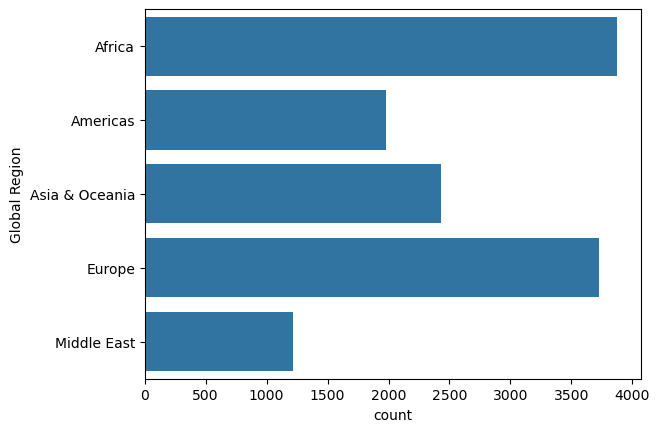

In [29]:
sns.countplot(df_m["Global Region"])
plt.show()

问题六：发现Global Region不是按照洲来划分的，对比不全面不明显怎么办

再看次区域军费开支分布情况

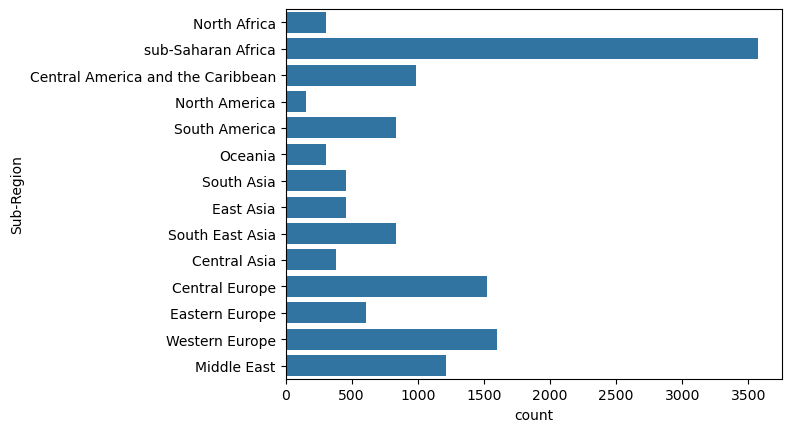

In [28]:
sns.countplot(df_m["Sub-Region"])
plt.show()

可以看到：
sub-Saharan Africa开支最大且远超第二
Middle East、Europe、America军费开支较高

再看主要国家军费开支情况

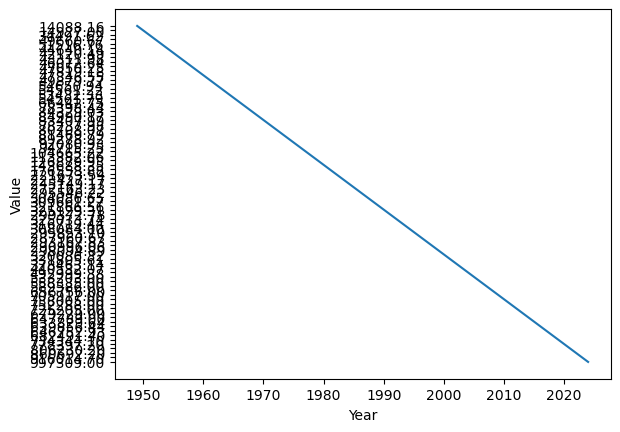

In [41]:
US_data=df_m[df_m["Country"]=="United States of America"]
sns.lineplot(data=US_data,x="Year",y="Value")
plt.show()

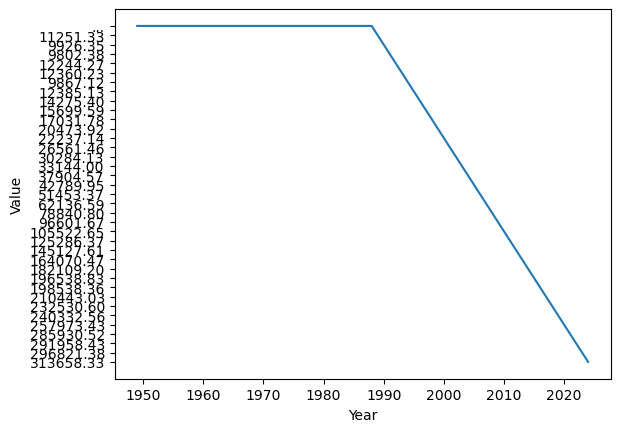

In [42]:
C_data=df_m[df_m["Country"]=="China"]
sns.lineplot(data=C_data,x="Year",y="Value")
plt.show()

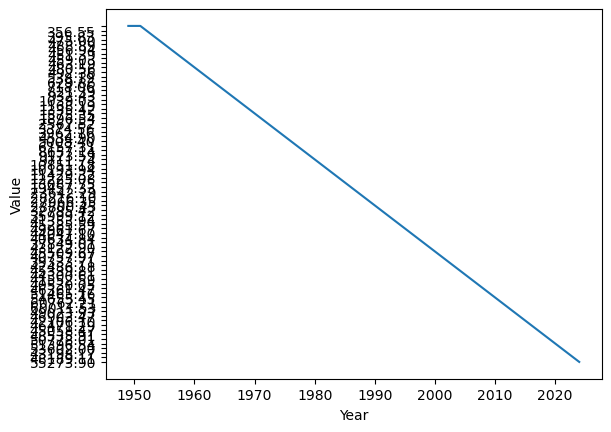

In [44]:
J_data=df_m[df_m["Country"]=="Japan"]
sns.lineplot(data=J_data,x="Year",y="Value")
plt.show()

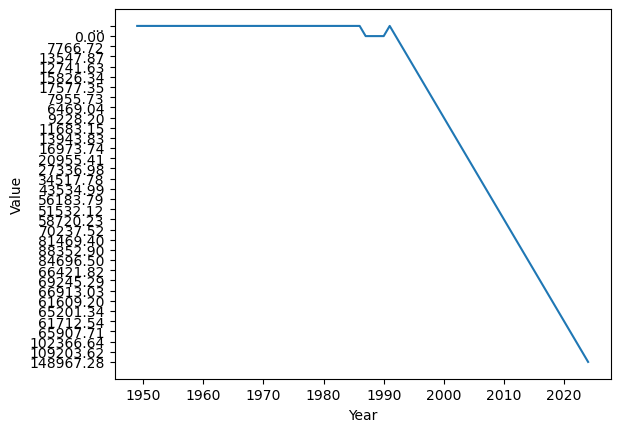

In [45]:
R_data=df_m[df_m["Country"]=="Russia"]
sns.lineplot(data=R_data,x="Year",y="Value")
plt.show()

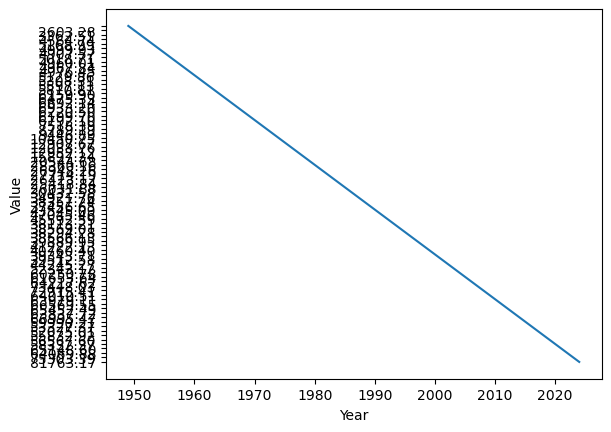

In [47]:
UK_data=df_m[df_m["Country"]=="United Kingdom"]
sns.lineplot(data=UK_data,x="Year",y="Value")
plt.show()

可以看出，世界主要大国军费开支每年稳定上涨

再对比各个主要大国的军费量

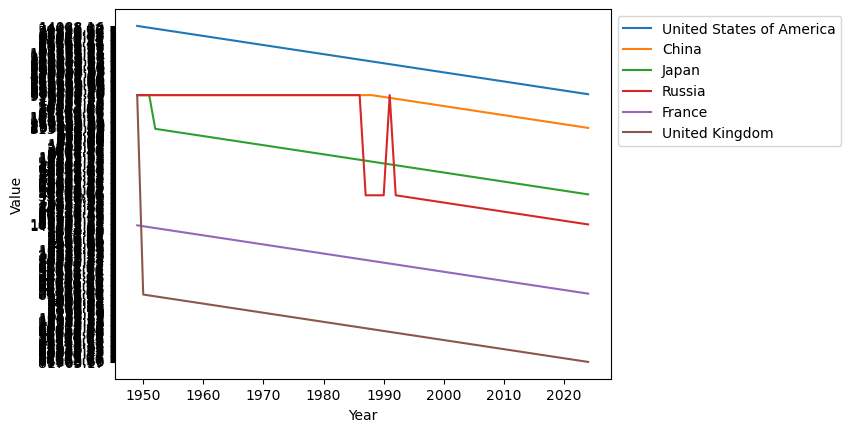

In [65]:
Big_Country=["United States of America","China","Russia","Japan","France","United Kingdom"]
sns.lineplot(data=df_m[df_m["Country"].isin(Big_Country)],x="Year",y="Value",hue="Country")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

问题七：如何仅抽出部分国家进行分析
方法：
Big_Country=["United States of America","China","Russia","Japan","France","United Kingdom"]
sns.lineplot(data=df_m[df_m["Country"].isin(Big_Country)],x="Year",y="Value",hue="Country")

问题八：如何将图例移开
方法：plt.legend(bbox_to_anchor=(1,1))

总结：
除俄罗斯存在短暂波动外，世界各国军费开支存在稳定上升趋势，印证了无政府状态之下的安全困境，是防御性现实主义理念的反映
世界和平发展之路任重道远